In [347]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM

In [348]:
def generate_structured_regression(n_samples=400, noise=0.1, seed=0):
    rng = np.random.default_rng(seed)
    
    x1 = rng.uniform(-2.0, 2.0, n_samples)
    x2 = x1**3 - 0.5*x1
    x2 = x2 + rng.normal(0, noise, n_samples)
    
    return x1.reshape(-1,1), x2.reshape(-1,1)


In [349]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


In [350]:
def train_svm_region(x1, x2):
    X = np.hstack([x1, x2])
    svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    svm.fit(X)
    return svm


In [351]:
class SVMPremise(nn.Module):
    def __init__(self, svm_model):
        super().__init__()
        
        self.support_vectors = torch.tensor(
            svm_model.support_vectors_, dtype=torch.float32
        )
        self.alpha = torch.tensor(
            svm_model.dual_coef_.flatten(), dtype=torch.float32
        )
        self.rho = torch.tensor(
            svm_model.intercept_[0], dtype=torch.float32
        )
        self.gamma = svm_model._gamma

    def rbf_kernel(self, X1, X2):
        sq1 = (X1**2).sum(dim=1, keepdim=True)
        sq2 = (X2**2).sum(dim=1, keepdim=True)
        sqdist = sq1 + sq2.T - 2 * X1 @ X2.T
        return torch.exp(-self.gamma * sqdist)

    def forward(self, x1, x2_pred):
        X = torch.cat([x1, x2_pred], dim=1)
        K = self.rbf_kernel(self.support_vectors, X)
        f = self.alpha @ K - self.rho
        return torch.relu(-f)


In [ ]:
"""
def train_model(x1, x2, mode="plain", lambda_premise=1.0, epochs=1000):
    
    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    x1_t = torch.tensor(x1, dtype=torch.float32)
    x2_t = torch.tensor(x2, dtype=torch.float32)

    # Train SVM only if needed
    if mode in ["combined", "premise_only"]:
        svm = train_svm_region(x1, x2)
        premise = SVMPremise(svm)
    else:
        premise = None

    for _ in range(epochs):
        optimizer.zero_grad()

        pred = model(x1_t)

        if mode == "plain":
            loss = criterion(pred, x2_t)

        elif mode == "combined":
            task_loss = criterion(pred, x2_t)
            premise_loss = premise(x1_t, pred).mean()
            loss = task_loss + lambda_premise * premise_loss

        elif mode == "premise_only":
            loss = premise(x1_t, pred).mean()

        else:
            raise ValueError("mode must be 'plain', 'combined', or 'premise_only'")

        loss.backward()
        optimizer.step()

    return model
"""

In [353]:
# =========================
# Simple Neural Network
# =========================
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# =========================
# Train SVM Region
# =========================
def train_svm_region(x1, x2):
    X = np.hstack([x1, x2])
    svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    svm.fit(X)
    return svm


# =========================
# Differentiable SVM Wrapper
# =========================
class SVMPremise(nn.Module):
    def __init__(self, svm_model):
        super().__init__()

        self.support_vectors = torch.tensor(
            svm_model.support_vectors_, dtype=torch.float32
        )
        self.alpha = torch.tensor(
            svm_model.dual_coef_.flatten(), dtype=torch.float32
        )
        self.rho = torch.tensor(
            svm_model.intercept_[0], dtype=torch.float32
        )
        self.gamma = svm_model._gamma

    def rbf_kernel(self, X1, X2):
        sq1 = (X1**2).sum(dim=1, keepdim=True)
        sq2 = (X2**2).sum(dim=1, keepdim=True)
        sqdist = sq1 + sq2.T - 2 * X1 @ X2.T
        return torch.exp(-self.gamma * sqdist)

    def raw_decision(self, x1, x2_pred):
        X = torch.cat([x1, x2_pred], dim=1)
        K = self.rbf_kernel(self.support_vectors, X)
        f = self.alpha @ K + self.rho
        return f

    def forward(self, x1, x2_pred):
        f = self.raw_decision(x1, x2_pred)
        return torch.relu(-f)   # penalty


# =========================
# Debug Helpers
# =========================
def debug_epoch(epoch, loss, model, premise, x1_t, pred, mode):
    print(f"\nEpoch: {epoch}")
    print("Loss:", loss.item())

    if mode != "plain" and premise is not None:
        with torch.no_grad():
            penalty_vals = premise(x1_t, pred)
            raw_vals = premise.raw_decision(x1_t, pred)

            print("Penalty min:", penalty_vals.min().item())
            print("Penalty max:", penalty_vals.max().item())

            print("Raw decision min:", raw_vals.min().item())
            print("Raw decision max:", raw_vals.max().item())

    print("Gradient norms:")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(f"{name}: {param.grad.norm().item()}")

    print("-" * 50)


def compare_svm_outputs(svm, premise, x1, x2):
    X_np = np.hstack([x1, x2])
    sklearn_vals = svm.decision_function(X_np)

    X_torch = torch.tensor(X_np, dtype=torch.float32)

    with torch.no_grad():
        K = premise.rbf_kernel(premise.support_vectors, X_torch)
        torch_vals = (premise.alpha @ K - premise.rho).numpy()

    diff = np.abs(sklearn_vals - torch_vals)

    print("Mean absolute difference:", diff.mean())
    print("Max absolute difference:", diff.max())


# =========================
# Training Function
# =========================
def train_model(x1, x2, mode="plain", lambda_premise=1.0, epochs=1000, debug=False):
    
    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    x1_t = torch.tensor(x1, dtype=torch.float32)
    x2_t = torch.tensor(x2, dtype=torch.float32)

    if mode in ["combined", "premise_only"]:
        svm = train_svm_region(x1, x2)
        premise = SVMPremise(svm)
    else:
        premise = None

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred = model(x1_t)

        if mode == "plain":
            loss = criterion(pred, x2_t)

        elif mode == "combined":
            task_loss = criterion(pred, x2_t)
            premise_loss = premise(x1_t, pred).mean()
            loss = task_loss + lambda_premise * premise_loss

        elif mode == "premise_only":
            premise_vals = premise(x1_t, pred)
            loss = premise_vals.mean()

        else:
            raise ValueError("mode must be 'plain', 'combined', or 'premise_only'")

        loss.backward()

        if debug and epoch % 100 == 0:
            debug_epoch(epoch, loss, model, premise, x1_t, pred, mode)

        optimizer.step()

    return model


In [354]:
# Generate data
x1, x2 = generate_structured_regression()

# Train models
#model_plain = train_model(x1, x2, use_premise=False)
#model_premise = train_model(x1, x2, use_premise=True, lambda_premise=0.5)


In [355]:
model_plain = train_model(x1, x2, mode="plain")

model_combined = train_model(x1, x2, mode="combined", lambda_premise=0.5)

model_premise = train_model(x1, x2, mode="premise_only")


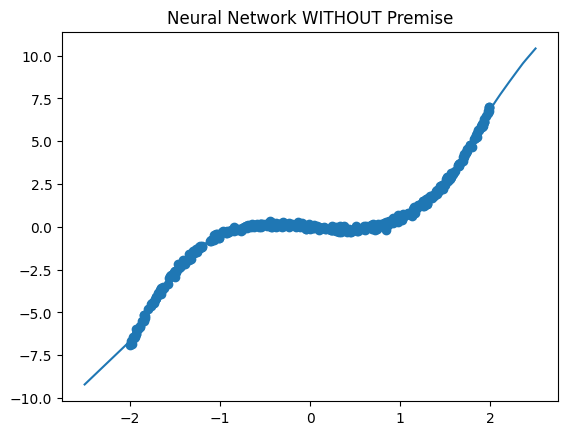

In [356]:
x1_test = np.linspace(-2.5, 2.5, 500).reshape(-1,1)
x1_test_t = torch.tensor(x1_test, dtype=torch.float32)

with torch.no_grad():
    y_plain = model_plain(x1_test_t).numpy()

plt.figure()
plt.scatter(x1, x2)
plt.plot(x1_test, y_plain)
plt.title("Neural Network WITHOUT Premise")
plt.show()


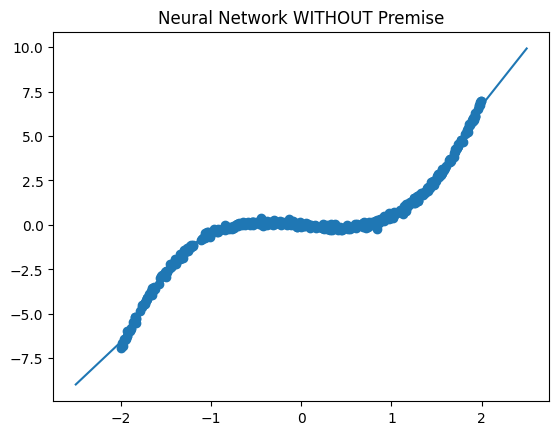

In [362]:
x1_test = np.linspace(-2.5, 2.5, 500).reshape(-1,1)
x1_test_t = torch.tensor(x1_test, dtype=torch.float32)

with torch.no_grad():
    y_plain = model_combined(x1_test_t).numpy()

plt.figure()
plt.scatter(x1, x2)
plt.plot(x1_test, y_plain)
plt.title("Neural Network WITHOUT Premise")
plt.show()


In [358]:
def plot_svm_region(svm, x1_range=(-2.5, 2.5), x2_range=(-5, 5), grid_size=400):
    
    x1_lin = np.linspace(*x1_range, grid_size)
    x2_lin = np.linspace(*x2_range, grid_size)
    
    xx, yy = np.meshgrid(x1_lin, x2_lin)
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    Z = svm.decision_function(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    
    # Feasible region (f(x) >= 0)
    plt.contourf(xx, yy, Z >= 0, alpha=0.2)
    
    # Decision boundary
    plt.contour(xx, yy, Z, levels=[0])
    
    plt.title("SVM Feasible Region")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


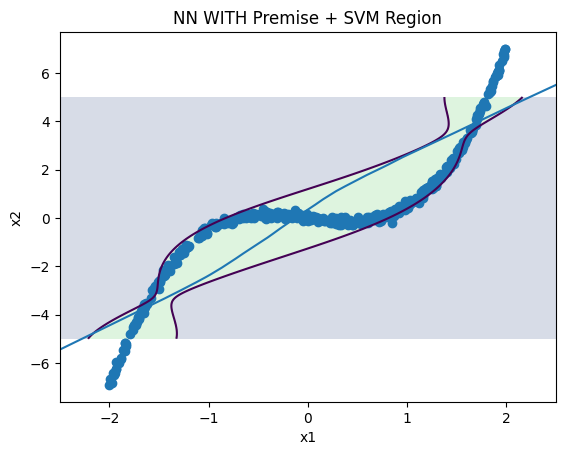

In [359]:
# Train SVM again to access it for plotting
svm = train_svm_region(x1, x2)

# Plot SVM region
#plot_svm_region(svm)

# Plot NN + Premise + Region together
x1_test = np.linspace(-2.5, 2.5, 500).reshape(-1,1)
x1_test_t = torch.tensor(x1_test, dtype=torch.float32)

with torch.no_grad():
    y_premise = model_premise(x1_test_t).numpy()

plt.figure()

# Plot region
x1_lin = np.linspace(-2.5, 2.5, 400)
x2_lin = np.linspace(-5, 5, 400)
xx, yy = np.meshgrid(x1_lin, x2_lin)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svm.decision_function(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z >= 0, alpha=0.2)
plt.contour(xx, yy, Z, levels=[0])

# Plot data
plt.scatter(x1, x2)

# Plot NN prediction
plt.plot(x1_test, y_premise)

plt.title("NN WITH Premise + SVM Region")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()
